# Criteo Day Selection — Coverage-Centric Coreset Selection (CCS)

Áp dụng thuật toán CCS từ paper **"Coverage-centric Coreset Selection for High Pruning Rates" (ICLR 2023)**.

## Ý tưởng cốt lõi
Thay vì chỉ dùng greedy set cover, CCS kết hợp:
1. **Importance score** — đo độ "khó/quan trọng" của từng ngày (drift so với phân phối trung bình)
2. **Stratified sampling** — đảm bảo budget phân bổ đều trên mọi mức importance, tránh bỏ qua "ngày dễ" nằm ở vùng high-density
3. **Hard cutoff** — cắt bỏ một số ngày outlier/noisy nhất (high importance nhưng không đại diện)

Tương ứng với bài toán gốc:
- Mỗi **example** trong paper → một **ngày** trong dataset
- **Pruning rate α** → tỷ lệ ngày bị loại bỏ
- **Importance score** → mức độ drift/dị thường của ngày so với toàn bộ dataset
- **Coverage** → AUCpr — khoảng cách trung bình từ các ngày KHÔNG được chọn đến ngày gần nhất được chọn

## Bước 0: Đăng nhập HuggingFace

In [ ]:
from huggingface_hub import login
login()  # Nhập token từ https://huggingface.co/settings/tokens

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Bước 1: Import và cấu hình

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import pyarrow
import pyarrow.parquet as pq
import fsspec
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from huggingface_hub import HfFileSystem
from scipy.spatial.distance import cdist

# ── Tham số lấy mẫu ────────────────────────────────────────────────────────────
MAX_FILES_PER_DAY = 200      # Số file tối đa lấy mẫu trong một ngày
ROWS_PER_FILE     = 20_000  # Số dòng lấy mẫu trong mỗi file

# ── Tham số CCS ────────────────────────────────────────────────────────────────
PRUNING_RATE      = 0.875   # Giữ lại 3/24 ngày ≈ 12.5% → pruning 87.5%
HARD_CUTOFF_RATE  = 0.10    # Cắt 10% ngày có drift cao nhất trước khi stratify
N_STRATA          = 10      # Số strata chia theo importance score
                             # (paper dùng k=50 cho examples; với 24 ngày dùng k nhỏ hơn)

random.seed(42)
np.random.seed(42)
print("Cấu hình xong.")

Cấu hình xong.


## Bước 2: Quét danh sách ngày và lấy mẫu dấu vân tay (fingerprint)

In [ ]:
fs = HfFileSystem()

all_days = fs.ls("datasets/criteo/CriteoClickLogs/data", detail=False)
all_days = sorted([p.split("/")[-1] for p in all_days if "day=" in p])
print(f"Tìm thấy {len(all_days)} ngày: {all_days[:3]} ... {all_days[-3:]}")

Tìm thấy 24 ngày: ['day=2015-02-15', 'day=2015-02-16', 'day=2015-02-17'] ... ['day=2015-03-08', 'day=2015-03-09', 'day=2015-03-10']


In [ ]:
def sample_single_file(file_path, hf_fs, target_rows=20_000):
    """Đọc ngẫu nhiên target_rows dòng từ một parquet file dùng Row Groups."""
    try:
        with hf_fs.open(file_path, "rb") as f:
            parquet_file = pq.ParquetFile(f)
            all_cols  = parquet_file.schema.names
            label_col = next(c for c in all_cols if 'label' in c.lower() or c == 'click')
            num_cols  = [c for c in all_cols if c.startswith('i')][:13]
            cat_cols  = [c for c in all_cols if c.startswith('c')][:26]
            load_cols = [label_col] + num_cols + cat_cols

            rg_indices = list(range(parquet_file.num_row_groups))
            random.shuffle(rg_indices)

            batches, rows_collected = [], 0
            for rg_idx in rg_indices:
                if rows_collected >= target_rows:
                    break
                rg_table = parquet_file.read_row_group(rg_idx, columns=load_cols)
                batches.append(rg_table)
                rows_collected += rg_table.num_rows

            if not batches:
                return None

            full_table = pyarrow.concat_tables(batches)
            return full_table.to_pandas().sample(n=min(target_rows, rows_collected), random_state=42)
    except Exception as e:
        print(f"      ✗ Lỗi: {file_path.split('/')[-1]}: {e}")
        return None


def compute_fingerprint(day_folder, max_files=15, rows_per_file=20_000):
    """
    Lấy mẫu dữ liệu và trích xuất fingerprint thống kê của một ngày.
    Trả về dict chứa: ctr, mean/std/miss của 13 numerical cols,
    cardinality của 26 categorical cols.
    """
    files = fs.ls(f"datasets/criteo/CriteoClickLogs/data/{day_folder}", detail=True)
    parquet_files = [f['name'] for f in files if f['name'].endswith('.parquet')]
    if not parquet_files:
        raise ValueError(f"Không có file parquet trong {day_folder}")

    random.shuffle(parquet_files)
    selected_files = parquet_files[:max_files]
    print(f"   -> Chọn {len(selected_files)}/{len(parquet_files)} files...")

    hf_fs = fsspec.filesystem("hf", token=os.environ.get("HF_TOKEN"))
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(sample_single_file, fp, hf_fs, rows_per_file)
                   for fp in selected_files]
        dfs = [f.result() for f in futures if f.result() is not None]

    if not dfs:
        raise ValueError(f"Không lấy được dữ liệu cho {day_folder}")

    df = pd.concat(dfs, ignore_index=True)

    label_col = next(c for c in df.columns if 'label' in c.lower() or c == 'click')
    num_cols  = [c for c in df.columns if c.startswith('i')][:13]
    cat_cols  = [c for c in df.columns if c.startswith('c')][:26]

    fp = {'ctr': df[label_col].mean()}
    for col in num_cols:
        vals = df[col].dropna()
        fp[f'{col}_mean'] = vals.mean() if len(vals) else 0
        fp[f'{col}_std']  = vals.std()  if len(vals) else 0
        fp[f'{col}_miss'] = df[col].isna().mean()
    for col in cat_cols:
        fp[f'{col}_card'] = df[col].nunique()

    return fp, len(df)


# ── Thu thập fingerprint toàn bộ ngày ─────────────────────────────────────────
fingerprints = {}
for day in all_days:
    print(f"\n[SAMPLING] {day}")
    try:
        fp, n_rows = compute_fingerprint(day, MAX_FILES_PER_DAY, ROWS_PER_FILE)
        fingerprints[day] = fp
        print(f"   ✓ {n_rows:,} dòng | CTR = {fp['ctr']:.4f}")
    except Exception as e:
        print(f"   ✗ Thất bại: {e}")

print(f"\nThu thập xong fingerprint cho {len(fingerprints)}/{len(all_days)} ngày.")


[SAMPLING] day=2015-02-15
   -> Chọn 200/250 files...
   ✓ 4,000,000 dòng | CTR = 0.0320

[SAMPLING] day=2015-02-16
   -> Chọn 200/255 files...
   ✓ 4,000,000 dòng | CTR = 0.0317

[SAMPLING] day=2015-02-17
   -> Chọn 200/251 files...
   ✓ 4,000,000 dòng | CTR = 0.0318

[SAMPLING] day=2015-02-18
   -> Chọn 200/253 files...
   ✓ 4,000,000 dòng | CTR = 0.0322

[SAMPLING] day=2015-02-19
   -> Chọn 200/252 files...
   ✓ 4,000,000 dòng | CTR = 0.0345

[SAMPLING] day=2015-02-20
   -> Chọn 200/246 files...
   ✓ 4,000,000 dòng | CTR = 0.0338

[SAMPLING] day=2015-02-21
   -> Chọn 200/253 files...
   ✓ 4,000,000 dòng | CTR = 0.0317

[SAMPLING] day=2015-02-22
   -> Chọn 200/252 files...
   ✓ 4,000,000 dòng | CTR = 0.0332

[SAMPLING] day=2015-02-23
   -> Chọn 200/250 files...


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/criteo/CriteoClickLogs/resolve/main/data/day%3D2015-02-23/part-05425-99c339d5-fbac-4110-9dcf-75453a61a5c1.c000.snappy.parquet
Retrying in 1s [Retry 1/5].


   ✓ 4,000,000 dòng | CTR = 0.0330

[SAMPLING] day=2015-02-24
   -> Chọn 200/252 files...
   ✓ 4,000,000 dòng | CTR = 0.0333

[SAMPLING] day=2015-02-25
   -> Chọn 200/252 files...
   ✓ 4,000,000 dòng | CTR = 0.0330

[SAMPLING] day=2015-02-26
   -> Chọn 200/254 files...
   ✓ 4,000,000 dòng | CTR = 0.0352

[SAMPLING] day=2015-02-27
   -> Chọn 200/250 files...
   ✓ 4,000,000 dòng | CTR = 0.0343

[SAMPLING] day=2015-02-28
   -> Chọn 200/252 files...
   ✓ 4,000,000 dòng | CTR = 0.0323

[SAMPLING] day=2015-03-01
   -> Chọn 200/250 files...
   ✓ 4,000,000 dòng | CTR = 0.0323

[SAMPLING] day=2015-03-02
   -> Chọn 200/250 files...


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/criteo/CriteoClickLogs/resolve/main/data/day%3D2015-03-02/part-03570-99c339d5-fbac-4110-9dcf-75453a61a5c1.c000.snappy.parquet
Retrying in 1s [Retry 1/5].


   ✓ 4,000,000 dòng | CTR = 0.0326

[SAMPLING] day=2015-03-03
   -> Chọn 200/253 files...
   ✓ 4,000,000 dòng | CTR = 0.0337

[SAMPLING] day=2015-03-04
   -> Chọn 200/250 files...
   ✓ 4,000,000 dòng | CTR = 0.0333

[SAMPLING] day=2015-03-05
   -> Chọn 200/248 files...
   ✓ 4,000,000 dòng | CTR = 0.0354

[SAMPLING] day=2015-03-06
   -> Chọn 200/251 files...
   ✓ 4,000,000 dòng | CTR = 0.0350

[SAMPLING] day=2015-03-07
   -> Chọn 200/251 files...
   ✓ 4,000,000 dòng | CTR = 0.0325

[SAMPLING] day=2015-03-08
   -> Chọn 200/250 files...
   ✓ 4,000,000 dòng | CTR = 0.0327

[SAMPLING] day=2015-03-09
   -> Chọn 200/254 files...
   ✓ 4,000,000 dòng | CTR = 0.0327

[SAMPLING] day=2015-03-10
   -> Chọn 200/248 files...
   ✓ 4,000,000 dòng | CTR = 0.0338

Thu thập xong fingerprint cho 24/24 ngày.


## Bước 3: Tính Importance Score cho từng ngày

Trong CCS, **importance score** đo mức độ "khó" / "dị thường" của một example.

Với bài toán chọn ngày, một ngày **quan trọng / khó** = ngày có phân phối **khác nhiều** so với phân phối trung bình của toàn bộ dataset. Chúng ta dùng **weighted feature drift** làm importance score — tương tự AUM/Forgetting score trong paper.

In [ ]:
days = sorted(fingerprints.keys())
fp_df = pd.DataFrame(fingerprints).T.fillna(0)   # shape: [n_days, n_features]

# Normalize features (z-score) để các feature có scale khác nhau không bị dominance
fp_norm = (fp_df - fp_df.mean()) / (fp_df.std() + 1e-8)

# ── Tính Importance Score = Euclidean distance từ mỗi ngày đến centroid ────────
# Ngày có distance lớn = phân phối dị thường = "hard example" trong paper
centroid     = fp_norm.mean(axis=0)
importance   = np.linalg.norm(fp_norm.values - centroid.values, axis=1)
importance_s = pd.Series(importance, index=days, name='importance')

print("Importance scores (thấp = dễ/phổ biến, cao = khó/dị thường):")
print(importance_s.sort_values().to_string())
print(f"\nMin: {importance_s.min():.4f} | Mean: {importance_s.mean():.4f} | Max: {importance_s.max():.4f}")

Importance scores (thấp = dễ/phổ biến, cao = khó/dị thường):
day=2015-02-23     4.932079
day=2015-03-03     5.590682
day=2015-03-01     5.624943
day=2015-03-02     5.642992
day=2015-02-25     6.355633
day=2015-02-18     6.364899
day=2015-03-04     6.383168
day=2015-03-08     6.424275
day=2015-02-21     6.789569
day=2015-02-24     6.842890
day=2015-02-26     6.980984
day=2015-02-22     7.119391
day=2015-02-28     7.431466
day=2015-02-19     7.718455
day=2015-02-15     8.173919
day=2015-02-20     8.418539
day=2015-02-27     8.418729
day=2015-03-05     8.584187
day=2015-03-07     8.868063
day=2015-02-17     8.900014
day=2015-03-10     8.932670
day=2015-03-09     8.973285
day=2015-03-06     9.436421
day=2015-02-16    10.070155

Min: 4.9321 | Mean: 7.4574 | Max: 10.0702


## Bước 4: Tính Distance Matrix — AUCpr Coverage

Dùng khoảng cách cosine trong không gian feature (normalized) để đo mức độ "xa nhau" giữa các ngày.
AUCpr = khoảng cách trung bình từ mỗi ngày không được chọn đến ngày được chọn gần nhất.

In [ ]:
# Cosine distance matrix [n_days × n_days]
dist_matrix = cdist(fp_norm.values, fp_norm.values, metric='cosine')
np.fill_diagonal(dist_matrix, 0)
dist_df = pd.DataFrame(dist_matrix, index=days, columns=days)

def compute_aucpr(selected_days, all_days, dist_df):
    """
    AUCpr = khoảng cách trung bình từ mỗi ngày (toàn bộ) đến ngày được chọn gần nhất.
    Thấp hơn = coverage tốt hơn (Proposition 1 trong paper).
    """
    if not selected_days:
        return float('inf')
    distances_to_selected = dist_df[selected_days].min(axis=1)
    return distances_to_selected.mean()

flat = dist_matrix[dist_matrix > 0].flatten()
print(f"Distance stats: min={flat.min():.4f} | mean={flat.mean():.4f} | max={flat.max():.4f}")
print(f"  p25={np.percentile(flat,25):.4f} | p50={np.percentile(flat,50):.4f} | p75={np.percentile(flat,75):.4f}")

Distance stats: min=0.1652 | mean=1.0408 | max=1.7744
  p25=0.8085 | p50=1.0597 | p75=1.3131


## Bước 5: Coverage-Centric Coreset Selection (CCS)

Triển khai đúng Algorithm 1 từ paper:

```
Input: S (days + importance), α (pruning rate), β (hard cutoff), k (strata)
1. Cắt β% ngày có importance cao nhất (hard cutoff)
2. Chia các ngày còn lại thành k strata theo importance score
3. Phân bổ budget đều cho từng stratum (proportional to stratum size nhưng capped)
4. Lấy ngẫu nhiên từ mỗi stratum theo budget
```

Khác với greedy coverage cũ: **không ưu tiên ngày dị thường**, đảm bảo ngày phổ biến cũng được đại diện.

In [ ]:
def ccs_select(days, importance_s, pruning_rate, hard_cutoff_rate, n_strata, seed=42):
    """
    Coverage-Centric Coreset Selection — Algorithm 1 từ paper CCS (ICLR 2023).

    Parameters
    ----------
    days            : list of day strings
    importance_s    : pd.Series, importance score cho từng ngày (cao = khó = dị thường)
    pruning_rate    : float, tỷ lệ ngày bị loại (0.875 = giữ 3/24)
    hard_cutoff_rate: float, tỷ lệ ngày có importance cao nhất bị cắt trước
    n_strata        : int, số strata để chia importance score

    Returns
    -------
    selected : list of selected day strings
    info     : dict chứa thông tin debug
    """
    rng = np.random.default_rng(seed)
    n   = len(days)
    m   = round(n * (1 - pruning_rate))   # tổng budget = số ngày cần giữ lại
    print(f"Total days: {n} | Budget (keep): {m} | Pruning rate: {pruning_rate:.1%}")

    # ── Line 2: Hard cutoff — cắt β% ngày có importance cao nhất ───────────────
    # Lý do: ngày outlier thường chứa noise, không đại diện cho phân phối chung
    n_hard_cut  = round(n * hard_cutoff_rate)
    sorted_days = importance_s.sort_values(ascending=False)   # descending: khó nhất trên đầu
    hard_removed = list(sorted_days.index[:n_hard_cut])       # cắt n_hard_cut ngày khó nhất
    remaining    = list(sorted_days.index[n_hard_cut:])       # ngày còn lại sau hard cutoff
    print(f"Hard cutoff: loại {n_hard_cut} ngày dị thường nhất → còn {len(remaining)} ngày")
    if hard_removed:
        print(f"  Removed: {hard_removed}")

    # ── Lines 3-4: Chia thành k strata theo importance score ────────────────────
    # Mỗi stratum có range importance score bằng nhau (even range width)
    imp_remaining  = importance_s[remaining]
    score_min, score_max = imp_remaining.min(), imp_remaining.max()
    range_width = (score_max - score_min) / n_strata

    strata = []  # list of list (mỗi stratum là danh sách các ngày)
    for k in range(n_strata):
        lo = score_min + k * range_width
        hi = score_min + (k + 1) * range_width + (1e-9 if k == n_strata - 1 else 0)
        stratum = [d for d in remaining if lo <= imp_remaining[d] < hi]
        if stratum:
            strata.append(stratum)

    print(f"\nStrata ({len(strata)} non-empty / {n_strata} requested):")
    for i, st in enumerate(strata):
        scores = [imp_remaining[d] for d in st]
        print(f"  Stratum {i+1:2d} [{min(scores):.3f}, {max(scores):.3f}]: {len(st)} ngày → {st}")

    # ── Lines 7-13: Stratified sampling — phân bổ budget theo thuật toán CCS ───
    # Ưu tiên stratum ÍT ngày nhất trước (Bmin = arg min |B|)
    # → đảm bảo coverage: stratum thưa không bị bỏ qua dù có ít ngày hơn
    selected  = []
    remaining_budget  = m
    remaining_strata  = list(strata)   # copy để iterate

    print(f"\nStratified sampling (budget = {m}):")
    while remaining_strata and remaining_budget > 0:
        # Chọn stratum nhỏ nhất (fewest examples)
        remaining_strata.sort(key=len)
        B_min = remaining_strata.pop(0)

        # Budget cho stratum này = min(|B_min|, floor(total_budget / n_remaining_strata))
        fair_share = remaining_budget // (len(remaining_strata) + 1)
        budget_b   = min(len(B_min), max(1, fair_share))

        # Lấy ngẫu nhiên budget_b ngày từ stratum
        chosen = list(rng.choice(B_min, size=budget_b, replace=False))
        selected.extend(chosen)
        remaining_budget -= budget_b

        print(f"  Stratum {len(B_min)} days → pick {budget_b}: {chosen}  "
              f"(budget left: {remaining_budget})")

    info = {
        'hard_removed'  : hard_removed,
        'n_strata_actual': len(strata),
        'strata'        : strata,
    }
    return selected, info


# ── Chạy CCS ──────────────────────────────────────────────────────────────────
selected_ccs, ccs_info = ccs_select(
    days, importance_s,
    pruning_rate=PRUNING_RATE,
    hard_cutoff_rate=HARD_CUTOFF_RATE,
    n_strata=N_STRATA,
)

print(f"\n{'='*55}")
print(f"✅ CCS selected {len(selected_ccs)}/{len(days)} ngày:")
for d in sorted(selected_ccs):
    print(f"   - {d}  (importance: {importance_s[d]:.4f})")

Total days: 24 | Budget (keep): 3 | Pruning rate: 87.5%
Hard cutoff: loại 2 ngày dị thường nhất → còn 22 ngày
  Removed: ['day=2015-02-16', 'day=2015-03-06']

Strata (8 non-empty / 10 requested):
  Stratum  1 [4.932, 4.932]: 1 ngày → ['day=2015-02-23']
  Stratum  2 [5.591, 5.643]: 3 ngày → ['day=2015-03-02', 'day=2015-03-01', 'day=2015-03-03']
  Stratum  3 [6.356, 6.424]: 4 ngày → ['day=2015-03-08', 'day=2015-03-04', 'day=2015-02-18', 'day=2015-02-25']
  Stratum  4 [6.790, 6.843]: 2 ngày → ['day=2015-02-24', 'day=2015-02-21']
  Stratum  5 [6.981, 7.119]: 2 ngày → ['day=2015-02-22', 'day=2015-02-26']
  Stratum  6 [7.431, 7.718]: 2 ngày → ['day=2015-02-19', 'day=2015-02-28']
  Stratum  7 [8.174, 8.419]: 3 ngày → ['day=2015-02-27', 'day=2015-02-20', 'day=2015-02-15']
  Stratum  8 [8.584, 8.973]: 5 ngày → ['day=2015-03-09', 'day=2015-03-10', 'day=2015-02-17', 'day=2015-03-07', 'day=2015-03-05']

Stratified sampling (budget = 3):
  Stratum 1 days → pick 1: [np.str_('day=2015-02-23')]  (budg

## Bước 6: So sánh CCS vs Greedy (SOTA) vs Random

Dùng **AUCpr** (expected minimum distance) để đánh giá coverage — như Proposition 1 trong paper.
Giá trị thấp hơn = coverage tốt hơn = model accuracy cao hơn.

In [ ]:
def greedy_select(dist_df, n_select, epsilon_percentile=30):
    """Greedy coverage (SOTA baseline) — chọn ngày maximize coverage."""
    all_d   = list(dist_df.index)
    flat    = dist_df.values[dist_df.values > 0]
    epsilon = np.percentile(flat, epsilon_percentile)
    selected, covered = [], set()
    while len(selected) < n_select:
        best, best_gain = None, -1
        for d in all_d:
            if d in selected:
                continue
            new = {o for o in all_d if dist_df.loc[d, o] < epsilon}
            gain = len(new - covered)
            if gain > best_gain:
                best_gain, best = gain, d
        if best is None:
            break
        selected.append(best)
        covered |= {o for o in all_d if dist_df.loc[best, o] < epsilon}
    return selected

def importance_first_select(importance_s, n_select):
    """SOTA importance-based: chọn n_select ngày có importance CAO NHẤT."""
    return list(importance_s.nlargest(n_select).index)

n_select = len(selected_ccs)

# Baseline 1: Random
rng_b = np.random.default_rng(99)
selected_random = list(rng_b.choice(days, size=n_select, replace=False))

# Baseline 2: Importance-first (SOTA — chọn ngày dị thường nhất, dễ gây catastrophic drop)
selected_importance = importance_first_select(importance_s, n_select)

# Baseline 3: Greedy coverage (phiên bản cũ trong code)
selected_greedy = greedy_select(dist_df, n_select)

# ── AUCpr cho mỗi phương pháp ─────────────────────────────────────────────────
methods = {
    'Random'            : selected_random,
    'Importance-first'  : selected_importance,
    'Greedy Coverage'   : selected_greedy,
    'CCS (Ours)'        : selected_ccs,
}

print(f"{'Method':<22} {'AUCpr':>8}  {'Selected days'}")
print("-" * 80)
aucpr_results = {}
for method, sel in methods.items():
    auc = compute_aucpr(sel, days, dist_df)
    aucpr_results[method] = auc
    label = '← lower is better'
    print(f"{method:<22} {auc:>8.5f}  {sorted(sel)}")

best_method = min(aucpr_results, key=aucpr_results.get)
print(f"\n🏆 Best AUCpr: {best_method} ({aucpr_results[best_method]:.5f})")

Method                    AUCpr  Selected days
--------------------------------------------------------------------------------
Random                  0.68496  [np.str_('day=2015-02-26'), np.str_('day=2015-03-05'), np.str_('day=2015-03-08')]
Importance-first        0.55533  ['day=2015-02-16', 'day=2015-03-06', 'day=2015-03-09']
Greedy Coverage         0.50086  ['day=2015-02-17', 'day=2015-02-20', 'day=2015-03-08']
CCS (Ours)              0.63071  [np.str_('day=2015-02-23'), np.str_('day=2015-02-24'), np.str_('day=2015-02-26')]

🏆 Best AUCpr: Greedy Coverage (0.50086)


## Bước 7: Ablation Study — Thử các mức Pruning Rate khác nhau

Tái tạo Figure 5 / Table 1 của paper: so sánh AUCpr theo pruning rate.

In [ ]:
pruning_rates  = [0.50, 0.625, 0.75, 0.833, 0.875]   # giữ 12, 9, 6, 4, 3 ngày
ablation_results = defaultdict(dict)

print(f"{'Pruning':>8} {'Keep':>5} | {'Random':>8} {'Importance':>11} {'Greedy':>8} {'CCS':>8}")
print("-" * 65)

for alpha in pruning_rates:
    k = max(1, round(len(days) * (1 - alpha)))

    rng_tmp = np.random.default_rng(42)
    sel_rand = list(rng_tmp.choice(days, size=k, replace=False))
    sel_imp  = importance_first_select(importance_s, k)
    sel_grdy = greedy_select(dist_df, k)
    sel_ccs, _ = ccs_select(days, importance_s, alpha, HARD_CUTOFF_RATE, N_STRATA, seed=42)

    auc_rand = compute_aucpr(sel_rand, days, dist_df)
    auc_imp  = compute_aucpr(sel_imp,  days, dist_df)
    auc_grdy = compute_aucpr(sel_grdy, days, dist_df)
    auc_ccs  = compute_aucpr(sel_ccs,  days, dist_df)

    for method, auc in [('Random', auc_rand), ('Importance', auc_imp),
                        ('Greedy', auc_grdy), ('CCS', auc_ccs)]:
        ablation_results[method][alpha] = auc

    print(f"{alpha:>7.1%} {k:>5d} | {auc_rand:>8.5f} {auc_imp:>11.5f} {auc_grdy:>8.5f} {auc_ccs:>8.5f}")

 Pruning  Keep |   Random  Importance   Greedy      CCS
-----------------------------------------------------------------
Total days: 24 | Budget (keep): 12 | Pruning rate: 50.0%
Hard cutoff: loại 2 ngày dị thường nhất → còn 22 ngày
  Removed: ['day=2015-02-16', 'day=2015-03-06']

Strata (8 non-empty / 10 requested):
  Stratum  1 [4.932, 4.932]: 1 ngày → ['day=2015-02-23']
  Stratum  2 [5.591, 5.643]: 3 ngày → ['day=2015-03-02', 'day=2015-03-01', 'day=2015-03-03']
  Stratum  3 [6.356, 6.424]: 4 ngày → ['day=2015-03-08', 'day=2015-03-04', 'day=2015-02-18', 'day=2015-02-25']
  Stratum  4 [6.790, 6.843]: 2 ngày → ['day=2015-02-24', 'day=2015-02-21']
  Stratum  5 [6.981, 7.119]: 2 ngày → ['day=2015-02-22', 'day=2015-02-26']
  Stratum  6 [7.431, 7.718]: 2 ngày → ['day=2015-02-19', 'day=2015-02-28']
  Stratum  7 [8.174, 8.419]: 3 ngày → ['day=2015-02-27', 'day=2015-02-20', 'day=2015-02-15']
  Stratum  8 [8.584, 8.973]: 5 ngày → ['day=2015-03-09', 'day=2015-03-10', 'day=2015-02-17', 'day=2015

## Bước 8: Visualization

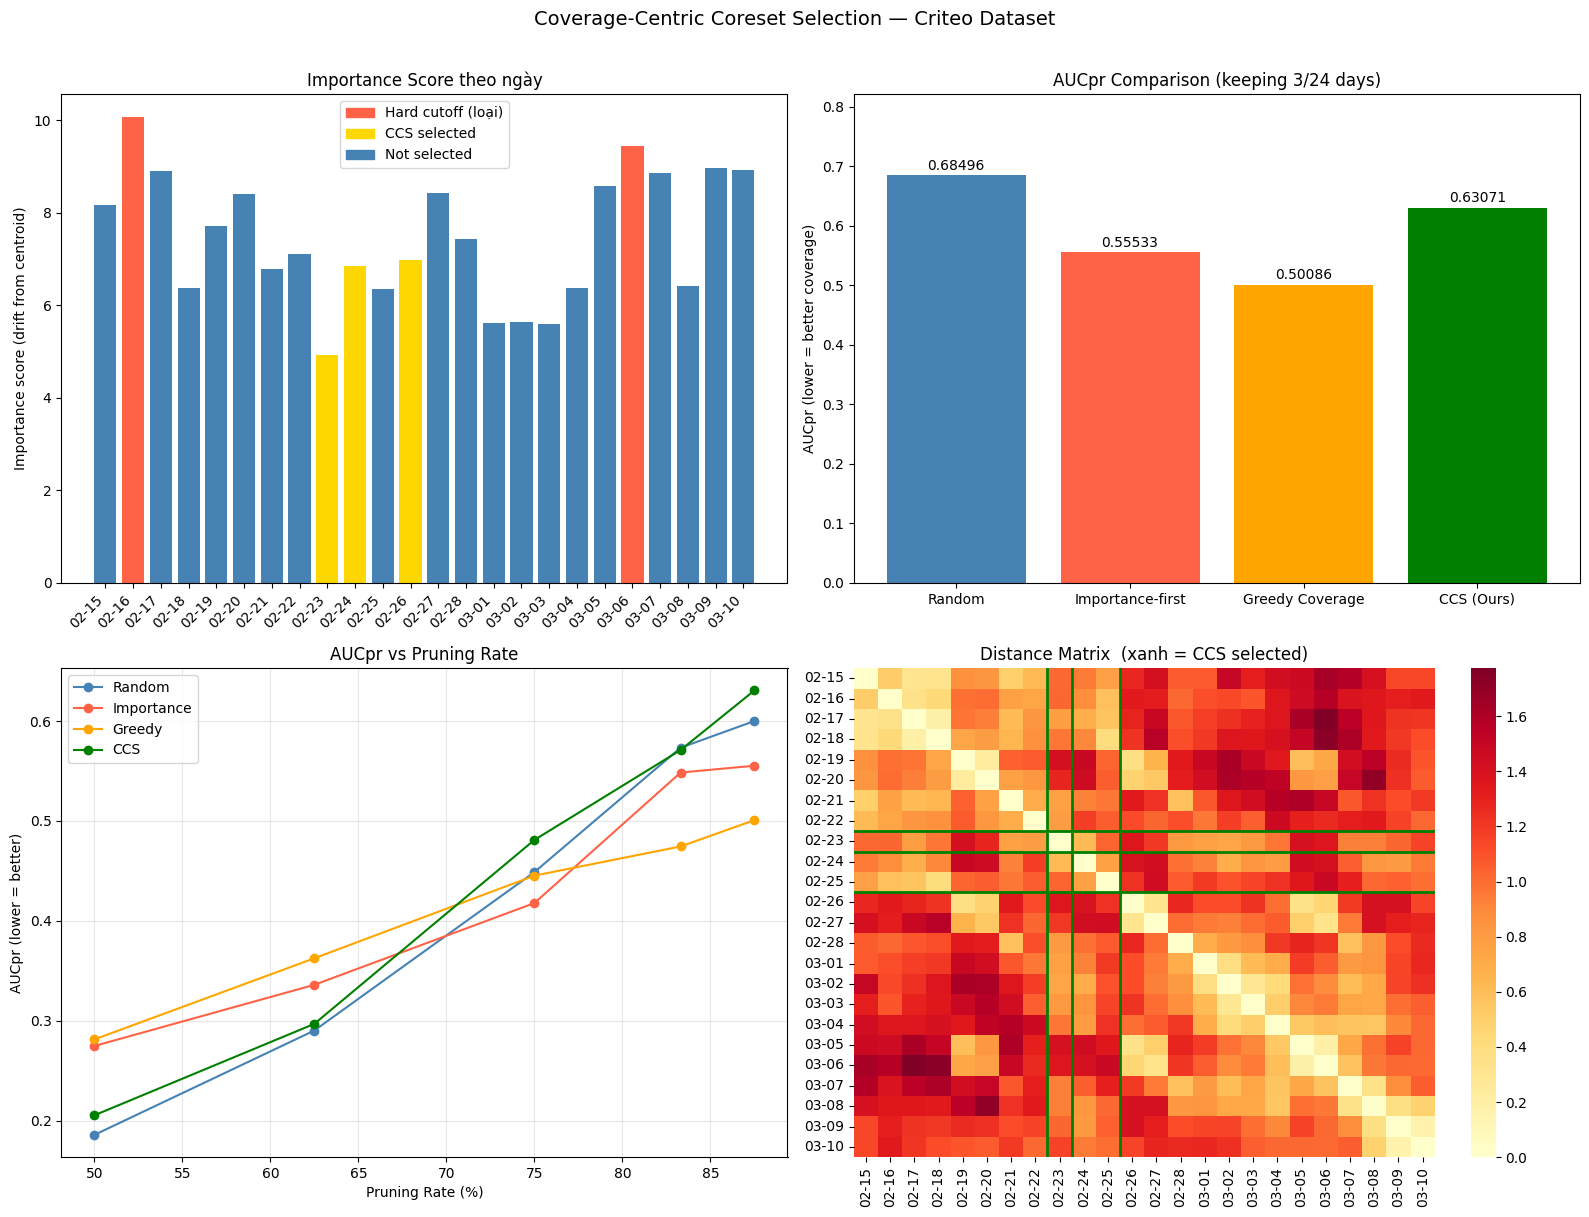

Đã lưu: ccs_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Importance score theo ngày ─────────────────────────────────────────────
ax = axes[0, 0]
colors = ['tomato' if d in ccs_info['hard_removed'] else
          'gold'   if d in selected_ccs else
          'steelblue' for d in days]
ax.bar(range(len(days)), importance_s[days].values, color=colors)
ax.set_xticks(range(len(days)))
ax.set_xticklabels([d.replace('day=2015-', '') for d in days], rotation=45, ha='right')
ax.set_ylabel('Importance score (drift from centroid)')
ax.set_title('Importance Score theo ngày')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='tomato',    label='Hard cutoff (loại)'),
    Patch(color='gold',      label='CCS selected'),
    Patch(color='steelblue', label='Not selected'),
])

# ── 2. AUCpr so sánh các phương pháp ─────────────────────────────────────────
ax = axes[0, 1]
method_colors = {'Random': 'steelblue', 'Importance-first': 'tomato',
                 'Greedy Coverage': 'orange', 'CCS (Ours)': 'green'}
bars = ax.bar(methods.keys(), [aucpr_results[m] for m in methods],
              color=[method_colors[m] for m in methods])
ax.bar_label(bars, fmt='%.5f', padding=2)
ax.set_ylabel('AUCpr (lower = better coverage)')
ax.set_title(f'AUCpr Comparison (keeping {n_select}/{len(days)} days)')
ax.set_ylim(0, max(aucpr_results.values()) * 1.2)

# ── 3. AUCpr vs Pruning Rate (tái tạo Figure 1 từ paper) ─────────────────────
ax = axes[1, 0]
method_colors2 = {'Random': 'steelblue', 'Importance': 'tomato',
                  'Greedy': 'orange', 'CCS': 'green'}
for method, color in method_colors2.items():
    alphas = sorted(ablation_results[method].keys())
    aucs   = [ablation_results[method][a] for a in alphas]
    ax.plot([a * 100 for a in alphas], aucs, 'o-', label=method, color=color)
ax.set_xlabel('Pruning Rate (%)')
ax.set_ylabel('AUCpr (lower = better)')
ax.set_title('AUCpr vs Pruning Rate')
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Distance heatmap với CCS selected highlighted ─────────────────────────
ax = axes[1, 1]
sns.heatmap(dist_df, annot=False, cmap='YlOrRd', ax=ax,
            xticklabels=[d.replace('day=2015-', '') for d in days],
            yticklabels=[d.replace('day=2015-', '') for d in days])
for d in selected_ccs:
    idx = days.index(d)
    ax.axhline(y=idx,   color='green', linewidth=2)
    ax.axvline(x=idx,   color='green', linewidth=2)
ax.set_title('Distance Matrix  (xanh = CCS selected)')

plt.suptitle('Coverage-Centric Coreset Selection — Criteo Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ccs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: ccs_analysis.png")

## Bước 9: Validation Report — Feature Mean Preservation


 Random  (n=3)
  AUCpr          : 0.68496
  Mean feat err  : 2.24%
  Max feat err   : 4.78%  (integer_feature_6_mean)
  Features > 10% : 0

 Importance-first  (n=3)
  AUCpr          : 0.55533
  Mean feat err  : 0.89%
  Max feat err   : 2.93%  (integer_feature_6_mean)
  Features > 10% : 0

 Greedy Coverage  (n=3)
  AUCpr          : 0.50086
  Mean feat err  : 1.14%
  Max feat err   : 4.06%  (integer_feature_1_mean)
  Features > 10% : 0

 CCS (Ours)  (n=3)
  AUCpr          : 0.63071
  Mean feat err  : 0.96%
  Max feat err   : 4.10%  (integer_feature_1_mean)
  Features > 10% : 0


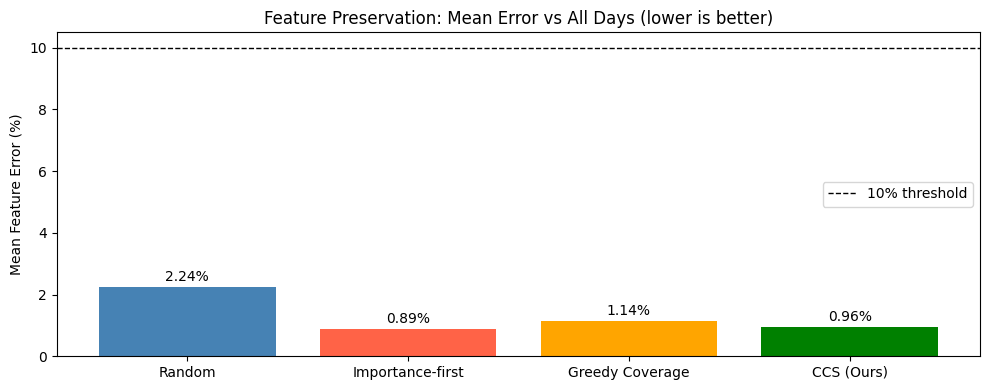

In [ ]:
all_fp_df = pd.DataFrame(fingerprints).T

def validation_report(selected, all_fp_df, label):
    sel_fp     = all_fp_df.loc[selected]
    global_mu  = all_fp_df.mean()
    sel_mu     = sel_fp.mean()
    errors     = (sel_mu - global_mu).abs() / (global_mu.abs() + 1e-10) * 100

    # Chỉ report các key metrics
    key_cols = [c for c in all_fp_df.columns if c == 'ctr' or c.endswith('_mean')][:14]
    errors_k = errors[key_cols]

    print(f"\n{'='*60}")
    print(f" {label}  (n={len(selected)})")
    print(f"{'='*60}")
    print(f"  AUCpr          : {compute_aucpr(selected, days, dist_df):.5f}")
    print(f"  Mean feat err  : {errors_k.mean():.2f}%")
    print(f"  Max feat err   : {errors_k.max():.2f}%  ({errors_k.idxmax()})")
    print(f"  Features > 10% : {(errors_k > 10).sum()}")
    return errors_k

errs = {}
for method, sel in methods.items():
    errs[method] = validation_report(sel, all_fp_df, method)

# ── Bar chart: mean feature error per method ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
method_list = list(methods.keys())
mean_errors = [errs[m].mean() for m in method_list]
bar_colors  = [method_colors.get(m, 'gray') for m in method_list]
bars = ax.bar(method_list, mean_errors, color=bar_colors)
ax.bar_label(bars, fmt='%.2f%%', padding=2)
ax.axhline(10, color='black', linestyle='--', linewidth=1, label='10% threshold')
ax.set_ylabel('Mean Feature Error (%)')
ax.set_title('Feature Preservation: Mean Error vs All Days (lower is better)')
ax.legend()
plt.tight_layout()
plt.show()

## Bước 10: Download dữ liệu của các ngày được chọn

In [ ]:
from huggingface_hub import hf_hub_url
from huggingface_hub.utils import build_hf_headers
import requests

SELECTED_DAYS = sorted(selected_ccs)
print(f"Sẽ download {len(SELECTED_DAYS)} ngày: {SELECTED_DAYS}")


def download_full_day(day_folder, cache_dir="./criteo_data"):
    """Download toàn bộ parquet files của một ngày."""
    os.makedirs(cache_dir, exist_ok=True)
    files = fs.ls(f"datasets/criteo/CriteoClickLogs/data/{day_folder}", detail=True)
    parquet_files = [f for f in files if f['name'].endswith('.parquet')]

    dfs = []
    for i, file_info in enumerate(parquet_files):
        rel_path = file_info['name'].replace("datasets/criteo/CriteoClickLogs/", "")
        url      = hf_hub_url("criteo/CriteoClickLogs", rel_path, repo_type="dataset")
        headers  = build_hf_headers()
        tmp      = f"/tmp/criteo_{day_folder}_{i}.parquet"

        with requests.get(url, headers=headers, stream=True) as r:
            r.raise_for_status()
            with open(tmp, 'wb') as fout:
                for chunk in r.iter_content(1024 * 1024):
                    fout.write(chunk)

        dfs.append(pd.read_parquet(tmp))
        os.remove(tmp)
        print(f"  [{i+1}/{len(parquet_files)}] {rel_path.split('/')[-1][:40]} ✓")

    return pd.concat(dfs, ignore_index=True)


dataset = {}
for day in SELECTED_DAYS:
    print(f"\nDownloading {day} ...")
    dataset[day] = download_full_day(day)
    print(f"  ✅ {len(dataset[day]):,} dòng | "
          f"{dataset[day].memory_usage().sum()/1e9:.2f} GB RAM")

df_final = pd.concat(dataset.values(), ignore_index=True)
print(f"\n{'='*50}")
print(f"✅ df_final: {len(df_final):,} dòng × {len(df_final.columns)} cột")
print(f"   RAM      : {df_final.memory_usage().sum()/1e9:.2f} GB")
print(f"   CTR      : {df_final['label'].mean():.4f}")
print(f"   AUCpr of CCS selection: {compute_aucpr(SELECTED_DAYS, days, dist_df):.5f}")
print(f"   Data reduction: {len(days)} ngày → {len(SELECTED_DAYS)} ngày "
      f"({len(SELECTED_DAYS)/len(days):.1%} data giữ lại)")

Sẽ download 3 ngày: [np.str_('day=2015-02-23'), np.str_('day=2015-02-24'), np.str_('day=2015-02-26')]

  [1/250] part-00109-99c339d5-fbac-4110-9dcf-75453 ✓
  [2/250] part-00139-99c339d5-fbac-4110-9dcf-75453 ✓
  [3/250] part-00157-99c339d5-fbac-4110-9dcf-75453 ✓
  [4/250] part-00181-99c339d5-fbac-4110-9dcf-75453 ✓
  [5/250] part-00198-99c339d5-fbac-4110-9dcf-75453 ✓
  [6/250] part-00223-99c339d5-fbac-4110-9dcf-75453 ✓
  [7/250] part-00242-99c339d5-fbac-4110-9dcf-75453 ✓
  [8/250] part-00254-99c339d5-fbac-4110-9dcf-75453 ✓
  [9/250] part-00288-99c339d5-fbac-4110-9dcf-75453 ✓
  [10/250] part-00290-99c339d5-fbac-4110-9dcf-75453 ✓
  [11/250] part-00313-99c339d5-fbac-4110-9dcf-75453 ✓
  [12/250] part-00369-99c339d5-fbac-4110-9dcf-75453 ✓
  [13/250] part-00388-99c339d5-fbac-4110-9dcf-75453 ✓
  [14/250] part-00395-99c339d5-fbac-4110-9dcf-75453 ✓
  [15/250] part-00426-99c339d5-fbac-4110-9dcf-75453 ✓
  [16/250] part-00458-99c339d5-fbac-4110-9dcf-75453 ✓
  [17/250] part-00477-99c339d5-fbac-4110-9